In [177]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = True
DEBUG_QUERY = None
DEBUG_L = None

MAX_TIME = 1.25
FILE_NUM = 100

# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(0)

import sys

sys.setrecursionlimit(10**9)
if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
import heapq
import math
from collections import defaultdict

# =================================
# 共通
# =================================
if True:
    from importlib import reload

    import src.common as common

    reload(common)


from src.common import (
    Env,
    EnvOffline,
    UnionFind,
    calc_dist,
    calc_rectangle_dist_min_max,
    construct_dag_and_rdag_from_edges,
    construct_dag_from_edges,
    construct_dist_matrix,
    construct_dist_matrix_rectangle,
    construct_graph,
    construct_sorted_edges,
    cut_graph,
    divide_interval,
    exponential_schedule,
    is_overlap,
    kruskals_algorithm,
    linear_schedule,
    my_deepcopy,
    prim,
    prim_k,
    prim_vs,
    priority_topological_sort,
    scc,
    scc_construct,
    sort_pair,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")

In [178]:
def calc_edge_list(env, points):
    edge_dists = []
    edge_id = 0
    for i in range(env.N):
        for j in range(i + 1, env.N):
            dist = calc_dist(points[i], points[j])
            edge_dists.append((dist, edge_id))
            edge_id += 1
    return sorted(edge_dists, key=lambda x: x[0])


def rank_sqrt_error(rank1, rank2):
    N = len(rank1)
    rank2_num_to_rank = {}
    for i, r2 in enumerate(rank2):
        rank2_num_to_rank[r2] = i

    cost = 0
    for i, v in enumerate(rank1):
        cost += abs(i - rank2_num_to_rank[v]) ** 2

    return cost / N


def rank_error(rank1, rank2):
    N = len(rank1)
    rank2_num_to_rank = {}
    for i, r2 in enumerate(rank2):
        rank2_num_to_rank[r2] = i

    cost = 0
    for i, v in enumerate(rank1):
        cost += abs(i - rank2_num_to_rank[v])

    return cost / N


def sorted_dag(
    vs: list[int],  # 頂点のリスト
    graph: dict[int, list[int]],  # 隣接リスト
    graph_r: dict[int, list[int]],  # 逆グラフ
    initial_ranking: list[int],  # 初期のランク
):
    """閉路を含むDAGを初期のランクに従ってソートする"""
    label_num, group = scc(graph, graph_r, vs)
    ssc_graph, belong_lists = scc_construct(graph, label_num, group, vs)

    num_to_ranking = {i: j for j, i in enumerate(initial_ranking)}
    construct_initial_ranking = {}
    for i, belong_list in enumerate(belong_lists):
        ssc_ranks = [num_to_ranking[v] for v in belong_list]
        n = len(ssc_ranks)
        mid_rank = sorted(ssc_ranks)[n // 2]
        construct_initial_ranking[i] = mid_rank

    result_rank_construct = priority_topological_sort(ssc_graph, construct_initial_ranking)
    result_rank = []
    for i in result_rank_construct:
        now_belong = belong_lists[i]
        result_rank.extend(now_belong)

    return result_rank

- グループ数分の点をランダム生成してクラスカル法をする

  - アルゴリズム
    - グループ数 M 個の点をランダム選択
    - M 点から繋がっている辺を全て heap に入れる
    - 全点つなぎ終えるまで繰り返す
      - 頂点数を増やしてはいけないグループを false にする
        - この判定はグループ数のソートをしたときに、元グループより各要素が小さくなれば良い
      - 最小辺を取り出すことを繰り返す
        - 繋げる辺の対象のグループが True であれば break
      - つなげた辺の先からつなげられる辺を全て追加する


In [179]:
file_num = 0
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

In [180]:
point_inds = list(range(env.N))
random_inds = random.sample(point_inds, env.M)
used = set(random_inds)
not_used = set(point_inds) - used
graph = construct_dist_matrix(env.cneter_points)

group_nums = [1 for _ in range(env.M)]
ans_edges = [[] for _ in range(env.M)]
ans_vs = [[] for _ in range(env.M)]
is_extend = [True for _ in range(env.M)]
belong_goups = [None for _ in range(env.N)]

for g, v in enumerate(random_inds):
    belong_goups[v] = g
    ans_vs[g].append(v)

que = []
heapq.heapify(que)
for v in random_inds:
    for nxt in range(env.N):
        if nxt in used:
            continue
        heapq.heappush(que, (graph[v][nxt], v, nxt))

sorted_true_g = sorted(env.G)
# while sum(group_nums) < env.N:
for _ in range(300):
    for g in range(env.M):
        tmp_group_nums = my_deepcopy(group_nums)
        tmp_group_nums[g] += 1
        tmp_group_nums = sorted(tmp_group_nums)
        for tg in range(env.M):
            if tmp_group_nums[tg] > sorted_true_g[tg]:
                is_extend[g] = False
                break
    while True:
        _, from_v, to_v = heapq.heappop(que)
        from_g = belong_goups[from_v]
        assert from_g is not None
        if not is_extend[from_g]:
            continue
        if to_v in used:
            continue

        used.add(to_v)
        ans_edges[from_g].append(sort_pair((from_v, to_v)))
        ans_vs[from_g].append(to_v)
        group_nums[from_g] += 1
        belong_goups[to_v] = from_g
        not_used.remove(to_v)

        for nxt in not_used:
            heapq.heappush(que, (graph[to_v][nxt], to_v, nxt))
        break

group_num_to_group_id = defaultdict(set)
for g, g_num in enumerate(env.G):
    group_num_to_group_id[g_num].add(g)

# sorted_ans_edges = [[] for _ in range(env.M)]
# sorted_ans_vs = [[] for _ in range(env.M)]
# for g in range(env.M):
#     group_num = len(ans_vs[g])
#     group_id = group_num_to_group_id[group_num].pop()
#     sorted_ans_edges[group_id] = ans_edges[g]
#     sorted_ans_vs[group_id] = ans_vs[g]

In [181]:
# for g in range(env.M):
#     assert len(set(sorted_ans_vs[g])) == env.G[g]
#     assert len(set(sorted_ans_edges[g])) == env.G[g] - 1

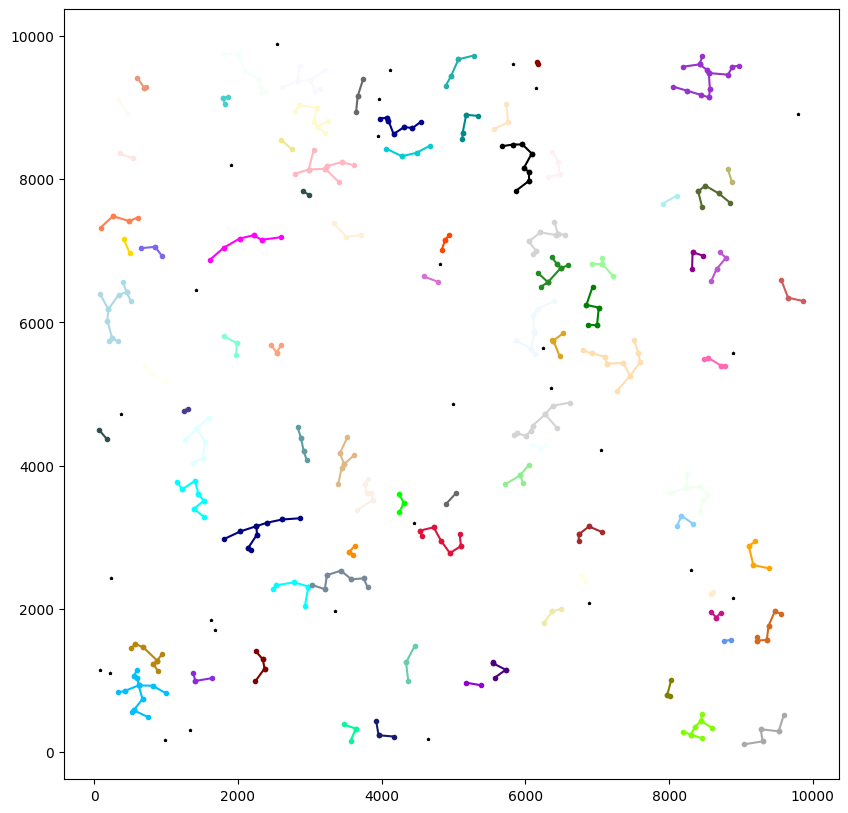

In [182]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


def get_color(i):
    colors = list(matplotlib.colors.CSS4_COLORS.values())
    return colors[i % len(colors)]


def draw_answer(ans_v, ans_edges):
    correct_coords = np.array(env.cneter_points)
    plt.figure(figsize=(10, 10))

    for g, (vs, edges) in enumerate(zip(ans_v, ans_edges)):
        if len(vs) == 1:
            coord = correct_coords[vs][0]
            plt.scatter(coord[0], coord[1], color="black", marker="*", s=3)
        vs = np.array(vs)
        edges = np.array(edges)
        for e in edges:
            cs = correct_coords[e]
            plt.plot(
                cs[:, 0],
                cs[:, 1],
                color=get_color(g),
                marker="o",
                markersize=3,
            )
    plt.show()


draw_answer(ans_vs, ans_edges)